In [1]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
import time
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

from torch.utils.data import TensorDataset, DataLoader

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error,
    r2_score
)

print("PyTorch version:", torch.__version__)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

PyTorch version: 2.11.0+cpu
Device: cpu


In [3]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("Random seed:", SEED)

Random seed: 42


In [4]:
V1_PATH = "/content/drive/MyDrive/IITG dataset/cleaned_dataset/processed_dataset_v1"

DATA_PATH = os.path.join(
    V1_PATH,
    "sequences_v1.npz"
)

print("Dataset path:", DATA_PATH)
print("Dataset exists:", os.path.exists(DATA_PATH))

Dataset path: /content/drive/MyDrive/IITG dataset/cleaned_dataset/processed_dataset_v1/sequences_v1.npz
Dataset exists: True


In [7]:
# Load Dataset V1

data = np.load(DATA_PATH)

X = data["X"]
y_soh = data["SoH"]
y_rul = data["RUL"]
battery_id = data["battery_id"]
split = data["split"]

print("X shape:", X.shape)
print("SoH shape:", y_soh.shape)
print("RUL shape:", y_rul.shape)
print("Battery ID shape:", battery_id.shape)
print("Split shape:", split.shape)

X shape: (2287, 10, 2)
SoH shape: (2287,)
RUL shape: (2287,)
Battery ID shape: (2287,)
Split shape: (2287,)


In [17]:
train_mask = split == "train"
val_mask = split == "validation"
test_mask = split == "test"

X_train = X[train_mask]
X_val = X[val_mask]
X_test = X[test_mask]

y_soh_train = y_soh[train_mask]
y_soh_val = y_soh[val_mask]
y_soh_test = y_soh[test_mask]

y_rul_train = y_rul[train_mask]
y_rul_val = y_rul[val_mask]
y_rul_test = y_rul[test_mask]

print("Training:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Training: (1516, 10, 2)
Validation: (379, 10, 2)
Test: (392, 10, 2)


In [18]:
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)

y_train_tensor = torch.tensor(
    np.column_stack([y_soh_train, y_rul_train]),
    dtype=torch.float32
)

y_val_tensor = torch.tensor(
    np.column_stack([y_soh_val, y_rul_val]),
    dtype=torch.float32
)

y_test_tensor = torch.tensor(
    np.column_stack([y_soh_test, y_rul_test]),
    dtype=torch.float32
)

print("Tensor conversion completed.")
print("X_train:", X_train_tensor.shape)
print("y_train:", y_train_tensor.shape)

Tensor conversion completed.
X_train: torch.Size([1516, 10, 2])
y_train: torch.Size([1516, 2])


In [19]:
BATCH_SIZE = 32

train_dataset = TensorDataset(
    X_train_tensor,
    y_train_tensor
)

val_dataset = TensorDataset(
    X_val_tensor,
    y_val_tensor
)

test_dataset = TensorDataset(
    X_test_tensor,
    y_test_tensor
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("DataLoaders created successfully.")
print("Batch size:", BATCH_SIZE)
print("Training batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))

DataLoaders created successfully.
Batch size: 32
Training batches: 48
Validation batches: 12
Test batches: 13


In [20]:
class TCNModel(nn.Module):

    def __init__(
        self,
        input_size=2,
        channels=(32, 64),
        kernel_size=3,
        dropout=0.2,
        output_size=2
    ):
        super(TCNModel, self).__init__()

        layers = []

        in_channels = input_size

        for i, out_channels in enumerate(channels):

            dilation = 2 ** i

            layers.append(
                TCNBlock(
                    in_channels,
                    out_channels,
                    kernel_size=kernel_size,
                    dilation=dilation,
                    dropout=dropout
                )
            )

            in_channels = out_channels

        self.tcn = nn.Sequential(*layers)

        self.fc = nn.Linear(
            channels[-1],
            output_size
        )

    def forward(self, x):

        # (batch, sequence, features)
        x = x.transpose(1, 2)

        # (batch, features, sequence)
        out = self.tcn(x)

        # Take the last time step
        out = out[:, :, -1]

        out = self.fc(out)

        return out


model = TCNModel().to(device)

print(model)

TCNModel(
  (tcn): Sequential(
    (0): TCNBlock(
      (conv1): Conv1d(2, 32, kernel_size=(3,), stride=(1,), padding=(2,))
      (relu1): ReLU()
      (dropout1): Dropout(p=0.2, inplace=False)
      (conv2): Conv1d(32, 32, kernel_size=(3,), stride=(1,), padding=(2,))
      (relu2): ReLU()
      (dropout2): Dropout(p=0.2, inplace=False)
      (downsample): Conv1d(2, 32, kernel_size=(1,), stride=(1,))
    )
    (1): TCNBlock(
      (conv1): Conv1d(32, 64, kernel_size=(3,), stride=(1,), padding=(4,), dilation=(2,))
      (relu1): ReLU()
      (dropout1): Dropout(p=0.2, inplace=False)
      (conv2): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(4,), dilation=(2,))
      (relu2): ReLU()
      (dropout2): Dropout(p=0.2, inplace=False)
      (downsample): Conv1d(32, 64, kernel_size=(1,), stride=(1,))
    )
  )
  (fc): Linear(in_features=64, out_features=2, bias=True)
)


In [21]:
criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

total_parameters = sum(
    p.numel()
    for p in model.parameters()
)

trainable_parameters = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print("Loss function:", criterion)
print("Optimizer: Adam")
print("Learning rate: 0.001")
print("Total parameters:", total_parameters)
print("Trainable parameters:", trainable_parameters)

Loss function: MSELoss()
Optimizer: Adam
Learning rate: 0.001
Total parameters: 24226
Trainable parameters: 24226


In [22]:
NUM_EPOCHS = 100

train_losses = []
val_losses = []

best_val_loss = float("inf")
best_epoch = 0

CHECKPOINT_PATH = os.path.join(
    V1_PATH,
    "tcn_best_model.pth"
)

start_time = time.time()

for epoch in range(NUM_EPOCHS):

    # Training
    model.train()

    running_train_loss = 0.0

    for X_batch, y_batch in train_loader:

        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        predictions = model(X_batch)

        loss = criterion(
            predictions,
            y_batch
        )

        loss.backward()
        optimizer.step()

        running_train_loss += (
            loss.item() * X_batch.size(0)
        )

    epoch_train_loss = (
        running_train_loss /
        len(train_loader.dataset)
    )

    # Validation
    model.eval()

    running_val_loss = 0.0

    with torch.no_grad():

        for X_batch, y_batch in val_loader:

            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            predictions = model(X_batch)

            loss = criterion(
                predictions,
                y_batch
            )

            running_val_loss += (
                loss.item() * X_batch.size(0)
            )

    epoch_val_loss = (
        running_val_loss /
        len(val_loader.dataset)
    )

    train_losses.append(epoch_train_loss)
    val_losses.append(epoch_val_loss)

    # Save best checkpoint
    if epoch_val_loss < best_val_loss:

        best_val_loss = epoch_val_loss
        best_epoch = epoch + 1

        torch.save(
            model.state_dict(),
            CHECKPOINT_PATH
        )

    if (epoch + 1) % 10 == 0 or epoch == 0:

        print(
            f"Epoch [{epoch+1:3d}/{NUM_EPOCHS}] "
            f"Train Loss: {epoch_train_loss:.6f} "
            f"Val Loss: {epoch_val_loss:.6f}"
        )

training_time = time.time() - start_time

print("\nTraining completed.")
print("Best Epoch:", best_epoch)
print("Best Validation Loss:", best_val_loss)
print(f"Training Time: {training_time:.2f} seconds")
print("Checkpoint:", CHECKPOINT_PATH)

Epoch [  1/100] Train Loss: 2207.843705 Val Loss: 794.107275
Epoch [ 10/100] Train Loss: 504.776416 Val Loss: 273.196806
Epoch [ 20/100] Train Loss: 462.340097 Val Loss: 267.942191
Epoch [ 30/100] Train Loss: 454.436102 Val Loss: 270.849409
Epoch [ 40/100] Train Loss: 448.051453 Val Loss: 283.204269
Epoch [ 50/100] Train Loss: 430.402946 Val Loss: 276.359650
Epoch [ 60/100] Train Loss: 425.553471 Val Loss: 281.213560
Epoch [ 70/100] Train Loss: 423.873706 Val Loss: 280.257549
Epoch [ 80/100] Train Loss: 418.588694 Val Loss: 286.718321
Epoch [ 90/100] Train Loss: 412.975613 Val Loss: 296.225621
Epoch [100/100] Train Loss: 402.547858 Val Loss: 306.571118

Training completed.
Best Epoch: 14
Best Validation Loss: 262.2310357810954
Training Time: 56.21 seconds
Checkpoint: /content/drive/MyDrive/IITG dataset/cleaned_dataset/processed_dataset_v1/tcn_best_model.pth


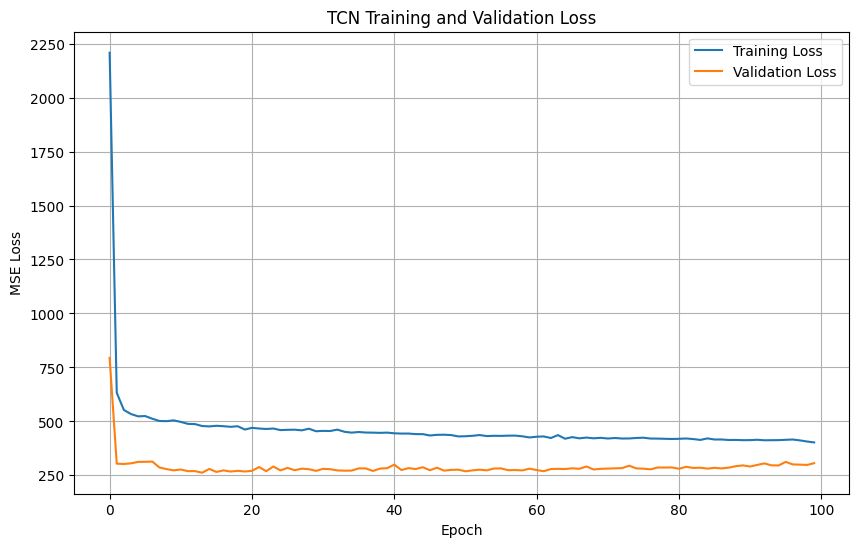

In [23]:
plt.figure(figsize=(10, 6))

plt.plot(
    train_losses,
    label="Training Loss"
)

plt.plot(
    val_losses,
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("TCN Training and Validation Loss")

plt.legend()
plt.grid(True)

plt.show()

In [24]:
model.load_state_dict(
    torch.load(
        CHECKPOINT_PATH,
        map_location=device
    )
)

model.eval()

print("Best TCN checkpoint loaded successfully.")
print("Best Epoch:", best_epoch)
print("Best Validation Loss:", best_val_loss)
print("Training Time:", f"{training_time:.2f} seconds")
print("Total Parameters:", total_parameters)

Best TCN checkpoint loaded successfully.
Best Epoch: 14
Best Validation Loss: 262.2310357810954
Training Time: 56.21 seconds
Total Parameters: 24226


In [25]:
all_predictions = []
all_targets = []

model.eval()

with torch.no_grad():

    for X_batch, y_batch in test_loader:

        X_batch = X_batch.to(device)

        predictions = model(X_batch)

        all_predictions.append(
            predictions.cpu().numpy()
        )

        all_targets.append(
            y_batch.numpy()
        )

y_pred = np.concatenate(
    all_predictions,
    axis=0
)

y_true = np.concatenate(
    all_targets,
    axis=0
)

print("Test evaluation completed.")
print("Actual shape:", y_true.shape)
print("Predicted shape:", y_pred.shape)

Test evaluation completed.
Actual shape: (392, 2)
Predicted shape: (392, 2)


In [26]:
soh_true = y_true[:, 0]
soh_pred = y_pred[:, 0]

rul_true = y_true[:, 1]
rul_pred = y_pred[:, 1]

print("SoH actual shape:", soh_true.shape)
print("SoH predicted shape:", soh_pred.shape)

print("RUL actual shape:", rul_true.shape)
print("RUL predicted shape:", rul_pred.shape)

SoH actual shape: (392,)
SoH predicted shape: (392,)
RUL actual shape: (392,)
RUL predicted shape: (392,)


In [27]:
def calculate_metrics(y_true, y_pred):

    mae = mean_absolute_error(
        y_true,
        y_pred
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_true,
            y_pred
        )
    )

    mape = (
        mean_absolute_percentage_error(
            y_true,
            y_pred
        ) * 100
    )

    r2 = r2_score(
        y_true,
        y_pred
    )

    return mae, rmse, mape, r2


soh_mae, soh_rmse, soh_mape, soh_r2 = calculate_metrics(
    soh_true,
    soh_pred
)

rul_mae, rul_rmse, rul_mape, rul_r2 = calculate_metrics(
    rul_true,
    rul_pred
)

tcn_results = pd.DataFrame({
    "Target": ["SoH", "RUL"],
    "MAE": [soh_mae, rul_mae],
    "RMSE": [soh_rmse, rul_rmse],
    "MAPE (%)": [soh_mape, rul_mape],
    "R2": [soh_r2, rul_r2]
})

print("TCN Test Results")
print("=" * 60)
print(tcn_results.to_string(index=False))

TCN Test Results
Target       MAE      RMSE     MAPE (%)         R2
   SoH 12.371353 17.157254 4.116007e+17  -0.233910
   RUL  2.912351  3.152259 1.238678e+18 -18.408663
